#Hidden data

In [37]:
from google.colab import drive
drive.mount('/content/drive')

Drive already mounted at /content/drive; to attempt to forcibly remount, call drive.mount("/content/drive", force_remount=True).


In [2]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt

from sklearn.model_selection import train_test_split

from sklearn.preprocessing import LabelEncoder
from sklearn.preprocessing import StandardScaler
from sklearn.cluster import KMeans
from sklearn.linear_model import LinearRegression
from sklearn.linear_model import Ridge
from sklearn.linear_model import Lasso

from sklearn.metrics import mean_squared_error

In [3]:
df = pd.read_csv('/content/drive/MyDrive/DS_P/synthetic_employee_data_hidden.csv')

df.head()

,EmployeeID,Age,Gender,Department,JobRole,EducationLevel,YearsAtCompany,MonthlyIncome,PerformanceRating,Attrition
0,E0001,NaN,Male,Sales,NaN,2.0,2.0,4679.0,1.0,No
1,E0002,24.0,Male,IT,Data Analyst,2.0,2.0,3434.0,2.0,NaN
2,E0003,56.0,NaN,HR,NaN,5.0,8.0,3106.0,2.0,No
3,E0004,43.0,Female,HR,HR Specialist,3.0,NaN,4519.0,4.0,Yes
4,E0005,NaN,Female,IT,UX Designer,NaN,3.0,9201.0,1.0,NaN


In [5]:
df.info()


<class 'pandas.core.frame.DataFrame'>
RangeIndex: 200 entries, 0 to 199
Data columns (total 10 columns):
 #   Column             Non-Null Count  Dtype  
---  ------             --------------  -----  
 0   EmployeeID         200 non-null    object 
 1   Age                162 non-null    float64
 2   Gender             171 non-null    object 
 3   Department         167 non-null    object 
 4   JobRole            157 non-null    object 
 5   EducationLevel     168 non-null    float64
 6   YearsAtCompany     164 non-null    float64
 7   MonthlyIncome      171 non-null    float64
 8   PerformanceRating  158 non-null    float64
 9   Attrition          156 non-null    object 
dtypes: float64(5), object(5)
memory usage: 15.8+ KB


In [6]:
df.describe()

,Age,EducationLevel,YearsAtCompany,MonthlyIncome,PerformanceRating
count,162.000000,168.000000,164.000000,171.000000,158.000000
mean,41.364198,3.136905,6.926829,7404.666667,2.626582
std,11.983817,1.455634,6.208604,2646.316008,1.012559
min,22.000000,1.000000,0.000000,3018.000000,1.000000
25%,30.000000,2.000000,2.000000,4886.500000,2.000000
50%,40.500000,3.000000,5.000000,7342.000000,3.000000
75%,52.750000,4.000000,12.000000,9757.500000,3.000000
max,60.000000,5.000000,20.000000,11938.000000,4.000000


In [7]:
df.columns

Index(['EmployeeID', 'Age', 'Gender', 'Department', 'JobRole',
       'EducationLevel', 'YearsAtCompany', 'MonthlyIncome',
       'PerformanceRating', 'Attrition'],
      dtype='object')

#Check Missing Values

In [8]:
df.isnull().sum()

,0
EmployeeID,0
Age,38
Gender,29
Department,33
JobRole,43
EducationLevel,32
YearsAtCompany,36
MonthlyIncome,29
PerformanceRating,42
Attrition,44


Summary statistics

In [9]:
df.describe()

,Age,EducationLevel,YearsAtCompany,MonthlyIncome,PerformanceRating
count,162.000000,168.000000,164.000000,171.000000,158.000000
mean,41.364198,3.136905,6.926829,7404.666667,2.626582
std,11.983817,1.455634,6.208604,2646.316008,1.012559
min,22.000000,1.000000,0.000000,3018.000000,1.000000
25%,30.000000,2.000000,2.000000,4886.500000,2.000000
50%,40.500000,3.000000,5.000000,7342.000000,3.000000
75%,52.750000,4.000000,12.000000,9757.500000,3.000000
max,60.000000,5.000000,20.000000,11938.000000,4.000000


# Prepare Data

Fill Missing Values   

Numerical Columns

In [10]:
num_cols = df.select_dtypes(include=np.number).columns

for col in num_cols:

    df[col] = df[col].fillna(df[col].mean())

Categorical Columns

In [11]:
cat_cols = df.select_dtypes(include='object').columns

for col in cat_cols:

    df[col] = df[col].fillna(df[col].mode()[0])

Encode Categorical Data

In [12]:
le = LabelEncoder()

for col in cat_cols:

    df[col] = le.fit_transform(df[col])

Remove useless columns

In [21]:
df = df.drop(['EmployeeID'], axis=1)

Choose Target Column :- like: [ MonthlyIncome ]

In [14]:
X = df.drop('MonthlyIncome', axis=1)

y = df['MonthlyIncome']

Split Data

In [15]:
X_train, X_test, y_train, y_test = train_test_split(
    X,
    y,
    test_size=0.2,
    random_state=42
)

Feature Scaling

In [22]:
from sklearn.preprocessing import StandardScaler

scaler = StandardScaler()

X_train = scaler.fit_transform(X_train)

X_test = scaler.transform(X_test)

#Exploratory Data Analysis (EDA) :- Visualizations
Histogram : Shows distribution

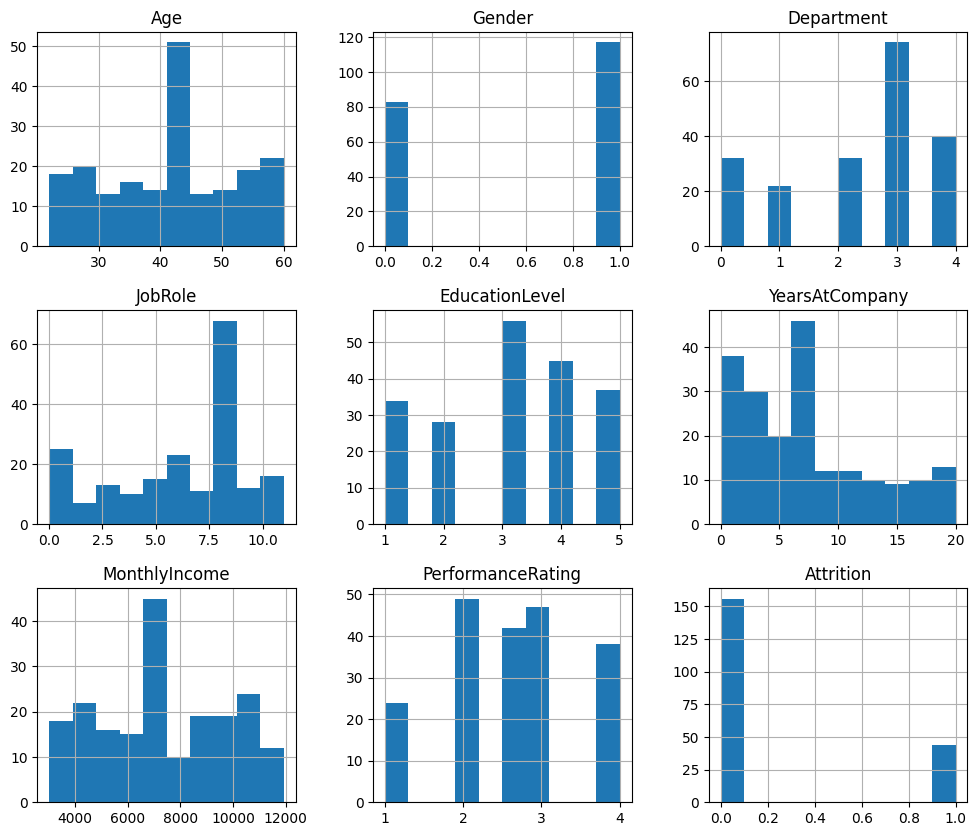

In [23]:
df.hist(figsize=(12,10))

plt.show()

Scatter Plot : the Best for regression

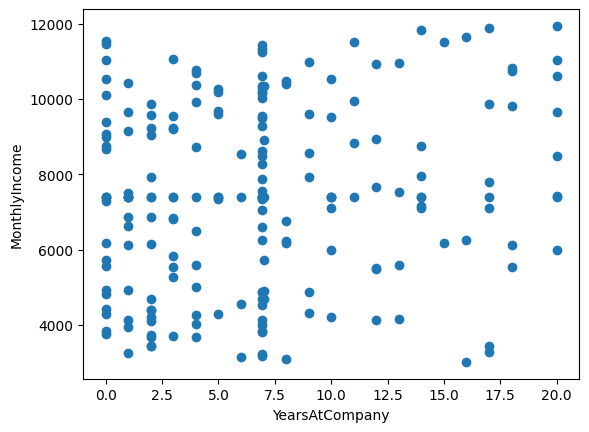

In [24]:
plt.scatter(df['YearsAtCompany'], df['MonthlyIncome'])

plt.xlabel('YearsAtCompany')

plt.ylabel('MonthlyIncome')

plt.show()

Bar Chart

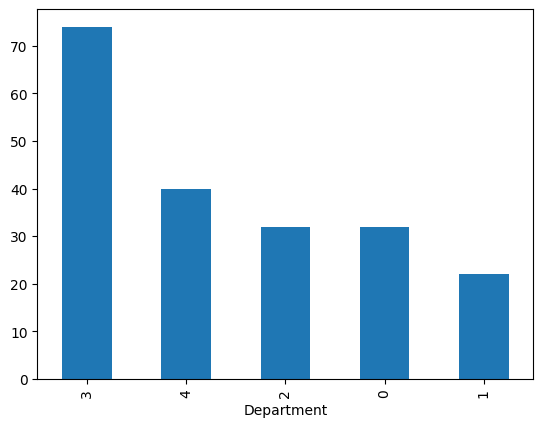

In [25]:
df['Department'].value_counts().plot(kind='bar')

plt.show()

Pie Chart

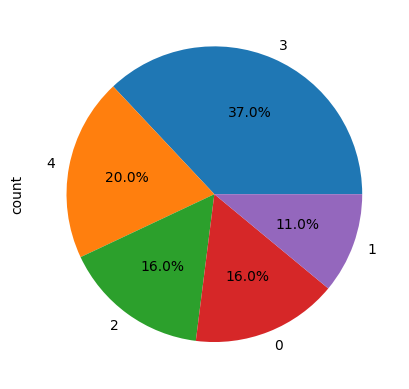

In [26]:
df['Department'].value_counts().plot(
    kind='pie',
    autopct='%1.1f%%'
)

plt.show()

#Grouping

In [29]:
df.groupby('Department')['MonthlyIncome'].mean()

,MonthlyIncome
Department,
0,8144.020833
1,6300.651515
2,7087.479167
3,7510.108108
4,7479.075000


##Linear Regression

In [30]:
lr = LinearRegression()

lr.fit(X_train, y_train)

lr_pred = lr.predict(X_test)

##Evaluate Linear Regression

In [31]:
mse = mean_squared_error(y_test, lr_pred)

rmse = np.sqrt(mse)

print("MSE:", mse)

print("RMSE:", rmse)

MSE: 5335871.589655244
RMSE: 2309.950560002366


##Ridge Regression

In [32]:
ridge = Ridge()

ridge.fit(X_train, y_train)

ridge_pred = ridge.predict(X_test)

##Evaluate Ridge

In [33]:
mse = mean_squared_error(y_test, ridge_pred)

rmse = np.sqrt(mse)

print("MSE:", mse)

print("RMSE:", rmse)

MSE: 5323655.793264868
RMSE: 2307.304876531246


##Lasso Regression

In [34]:
lasso = Lasso()

lasso.fit(X_train, y_train)

lasso_pred = lasso.predict(X_test)

##Evaluate Lasso

In [35]:
mse = mean_squared_error(y_test, lasso_pred)

rmse = np.sqrt(mse)

print("MSE:", mse)

print("RMSE:", rmse)

MSE: 5330375.460583396
RMSE: 2308.760589706823


#Compare Models

In [36]:
print("Linear Regression RMSE:", np.sqrt(mean_squared_error(y_test, lr_pred)))

print("Ridge Regression RMSE:", np.sqrt(mean_squared_error(y_test, ridge_pred)))

print("Lasso Regression RMSE:", np.sqrt(mean_squared_error(y_test, lasso_pred)))

Linear Regression RMSE: 2309.950560002366
Ridge Regression RMSE: 2307.304876531246
Lasso Regression RMSE: 2308.760589706823
